# Auto Feature Engineering & more

## Introduction  

This Notebook presents two key components of the Auto ML pipeline provided by Khiops:  

- [Auto Feature Engineering][auto_feature_engineering] which automatically generates a large number of informative aggregates from secondary tables of a multi-table training set,  
- [Parsimonious Training][parsimonious_training] which trains a model by selecting a small subset of independent and highly informative variables (native or aggregates).  

[auto_feature_engineering]: ../../../learn/autofeature_engineering/
[parsimonious_training]: ../../../learn/learning_models/


The sequencing of these two steps greatly improves *model interpretability*. To be more precise, data representation varies in size over the whole pipeline (see the figure bellow). On the one hand, Auto Feature Engineering explores a large number of aggregates, enriching the data representation with useful but possibly redundant information. On the other hand, Parsimonious Training reduces the data representation by selecting a *few informative and independent variables*. The contributions of the selected variables are almost additive, since their interactions are reduced to a minimum, making the model easy to interpret.

![](../../../assets/images/parcimonious-training-big-picture.webp)

Combined with the fact that the aggregates generated in the Auto Feature Engineering step have *explicit names*, this makes the models produced by Khiops very easy to understand. A *visualization tool* is provided for this purpose, making it possible to understand and visualize the entire Auto ML pipeline, from optimal encoding to model evaluation.

In this notebook, we'll explore the Khiops' Auto Feature Engineering capabilities which is unrivalled considering overfitting prevention, interpretability and scalability. We demonstrate that khiops' Auto Feature Engineering algorithm can be coupled to any classifier (here, using an LGBM classifier), dramatically improving the productivity of data scientists who no longer have to do feature engineering by hand. Finally, we demonstrate the benefits of using the full pipeline provided by Khiops, to leverage parsimonious training and considerably increase model interpretability. 

We will illustrate this using "Accidents" dataset. This dataset describes the characteristics of road accidents that occurred in France in 2018. It has three tables with the following schema:

```
Accidents
|
| -- 1:n -- Vehicles
              |
              |-- 1:n -- Users
```

## Installation and set up

If you do not use our official `khiops-notebook` Jupyter Docker image, you may have to install khiops locally using `conda`:

In [1]:
#!conda install -y -c conda-forge khiops

For the experiments, you also need some external libraries you can install via `pip`:

In [2]:
# Installation of external libraries
#!pip install matplotlib seaborn

# Note: Installing PyCaret can sometimes be complex due to its dependencies. 
# If you encounter any issues, please refer to the PyCaret documentation for detailed installation instructions:
# https://pycaret.gitbook.io/docs/get-started/installation
#!pip install pycaret

We now import all the dependencies here:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from khiops.sklearn import KhiopsClassifier
from khiops.sklearn import KhiopsEncoder

from pycaret.classification import *

## Import and preparation of data

For this notebook, we use the "Accident" French Dataset. More details on the [French Government Open Data Site][fr-open-data].

[fr-open-data]: https://www.data.gouv.fr/fr/datasets/base-de-donnees-accidents-corporels-de-la-circulation/

This dataset is also available on our [khiops-samples][khiops-samples] repository on Github.

[khiops-samples]: https://github.com/KhiopsML/khiops-samples/

This dataset has three tables `Accident`, `Vehicle`, and `User` organized in the following
relational schema.

```
Accident
|
| -- 1:n -- Vehicle
|             |
|             |-- 1:n -- User
```

Each accident has associated one or more vehicles. The vehicles involved in an
accident have in turn associated one or more road users (passengers and pedestrians).

The fields of each table need to be typed explicitly when read via `pandas.read_csv`,
especially when _typing confusions can be made_; most often, this applies to fields
which have numerical values, but are categorical in nature. For example:

- for the `Accident` table, this concerns columns `Department` and `Commune`: their
  values are integers, but the nature of these columns is categorical, because
  these are labels;
- for the `User` table, this concerns the `Seat` column: its values are also integers,
  but the nature of this column is categorical, because it identifies the seat the user
  was sitting on at the time of the accident.

The target in the `Accident` table is the constructed variable `Gravity` which is set to `Lethal` if
there was at least one casualty in the accident.

In [4]:
# Method 1: Load data directly from GitHub (recommended for quick tests or small datasets)
url_accidents = "https://raw.githubusercontent.com/KhiopsML/khiops-samples/11.0.0/Accidents/Accidents.txt"
accidents_df = pd.read_csv(url_accidents, delimiter="\t", dtype={
        "Department": pd.CategoricalDtype(),
        "Commune": pd.CategoricalDtype()
    }
)
# 
# Method 2: Load data locally after downloading all Khiops samples (best for offline use or large datasets)
# If the samples have not been downloaded yet:
# from khiops.tools import download_datasets
# download_datasets() 
# 
# from os import path
# from khiops import core as kh
# accidents_dataset_path = path.join(kh.get_samples_dir(), "AccidentsSummary")
# accidents_df = pd.read_csv(path.join(accidents_dataset_path, "Accidents.txt"), delimiter="\t", dtype={
#        "Department": pd.CategoricalDtype(),
#        "Commune": pd.CategoricalDtype()
#    }
#)

# Display the first 10 records from the dataset
accidents_df.head(10)


,AccidentId,Gravity,Date,Hour,Light,Department,Commune,InAgglomeration,IntersectionType,Weather,CollisionType,PostalAddress,GPSCode,Latitude,Longitude
0,201800000001,NonLethal,2018-01-24,15:05:00,Daylight,590,005,No,Y-type,Normal,2Vehicles-BehindVehicles-Frontal,route des Ansereuilles,M,50.55737,2.55737
1,201800000002,NonLethal,2018-02-12,10:15:00,Daylight,590,011,Yes,Square,VeryGood,NoCollision,Place du général de Gaul,M,50.52936,2.52936
2,201800000003,NonLethal,2018-03-04,11:35:00,Daylight,590,477,Yes,T-type,Normal,NoCollision,Rue nationale,M,50.51243,2.51243
3,201800000004,NonLethal,2018-05-05,17:35:00,Daylight,590,052,Yes,NoIntersection,VeryGood,2Vehicles-Side,30 rue Jules Guesde,M,50.51974,2.51974
4,201800000005,NonLethal,2018-06-26,16:05:00,Daylight,590,477,Yes,NoIntersection,Normal,2Vehicles-Side,72 rue Victor Hugo,M,50.51607,2.51607
5,201800000006,NonLethal,2018-09-23,06:30:00,TwilightOrDawn,590,052,Yes,NoIntersection,LightRain,Other,D39,M,50.52132,2.52132
6,201800000007,NonLethal,2018-09-26,00:40:00,NightStreelightsOn,590,133,Yes,NoIntersection,Normal,Other,4 route de camphin,M,50.52211,2.52211
7,201800000008,Lethal,2018-11-30,17:15:00,NightStreelightsOn,590,011,Yes,NoIntersection,Normal,Other,rue saint exupéry,M,50.53146,2.53146
8,201800000009,NonLethal,2018-02-18,15:57:00,Daylight,590,550,No,NoIntersection,Normal,Other,rue de l'égalité,M,50.53707,2.53707
9,201800000010,NonLethal,2018-03-19,15:30:00,Daylight,590,051,Yes,X-type,Normal,2Vehicles-BehindVehicles-Frontal,face au 59 rue de Lille,M,50.53639,2.53639


In [5]:
# Method 1: Load data directly from GitHub (recommended for quick tests or small datasets)
url_vehicle = "https://raw.githubusercontent.com/KhiopsML/khiops-samples/main/Accidents/Vehicles.txt"
vehicles_df = pd.read_csv(url_vehicle, delimiter='\t')

# Method 2: Load data locally after downloading all Khiops samples (best for offline use or large datasets)
# vehicles_df = pd.read_csv(path.join(accidents_dataset_path, "Vehicles.txt"), sep="\t")

# Display the first 10 records from the dataset
vehicles_df.head(10)


,AccidentId,VehicleId,Direction,Category,PassengerNumber,FixedObstacle,MobileObstacle,ImpactPoint,Maneuver
0,201800000001,A01,Unknown,Car<=3.5T,0,NaN,Vehicle,RightFront,TurnToLeft
1,201800000001,B01,Unknown,Car<=3.5T,0,NaN,Vehicle,LeftFront,NoDirectionChange
2,201800000002,A01,Unknown,Car<=3.5T,0,NaN,Pedestrian,NaN,NoDirectionChange
3,201800000003,A01,Unknown,Motorbike>125cm3,0,StationaryVehicle,Vehicle,Front,NoDirectionChange
4,201800000003,B01,Unknown,Car<=3.5T,0,NaN,Vehicle,LeftSide,TurnToLeft
5,201800000003,C01,Unknown,Car<=3.5T,0,NaN,NaN,RightSide,Parked
6,201800000004,A01,Unknown,Car<=3.5T,0,NaN,Other,RightFront,Avoidance
7,201800000004,B01,Unknown,Bicycle,0,NaN,Vehicle,LeftSide,NaN
8,201800000005,A01,Unknown,Moped,0,NaN,Vehicle,RightFront,PassLeft
9,201800000005,B01,Unknown,Car<=3.5T,0,NaN,Vehicle,LeftFront,Park


In [6]:
# Method 1: Load data directly from GitHub (recommended for quick tests or small datasets)
url_user = "https://raw.githubusercontent.com/KhiopsML/khiops-samples/main/Accidents/Users.txt"
users_df = pd.read_csv(url_user, delimiter='\t', dtype={
        "Seat": pd.CategoricalDtype()
    }
)

# Method 2: Load data locally after downloading all Khiops samples (best for offline use or large datasets)
# users_df = pd.read_csv(path.join(accidents_dataset_path, "Users.txt"), sep="\t", dtype={
#         "Seat": pd.CategoricalDtype()
#     }
# )

# Display the first 10 records from the dataset
users_df.head(10)

,AccidentId,VehicleId,Seat,Category,Gender,TripReason,SafetyDevice,SafetyDeviceUsed,PedestrianLocation,PedestrianAction,PedestrianCompany,BirthYear
0,201800000001,A01,1,Driver,Male,Leisure,SeatBelt,Yes,NaN,NaN,Unknown,1960.0
1,201800000001,B01,1,Driver,Male,NaN,SeatBelt,Yes,NaN,NaN,Unknown,1928.0
2,201800000002,A01,1,Driver,Male,NaN,SeatBelt,Yes,NaN,NaN,Unknown,1947.0
3,201800000002,A01,NaN,Pedestrian,Male,NaN,Helmet,NaN,OnLane<=OnSidewalk0mCrossing,Crossing,Alone,1959.0
4,201800000003,A01,1,Driver,Male,Leisure,Helmet,Yes,NaN,NaN,Unknown,1987.0
5,201800000003,C01,1,Driver,Male,NaN,ChildrenDevice,NaN,NaN,NaN,Unknown,1977.0
6,201800000004,A01,1,Driver,Male,Leisure,SeatBelt,Yes,NaN,NaN,Unknown,1982.0
7,201800000004,B01,1,Driver,Male,Leisure,Helmet,NaN,NaN,NaN,Unknown,2013.0
8,201800000005,A01,1,Driver,Male,Leisure,Helmet,Yes,NaN,NaN,Unknown,2001.0
9,201800000005,B01,1,Driver,Male,Leisure,SeatBelt,Yes,NaN,NaN,Unknown,1946.0


We need a final step to remove the target from the main table :

In [7]:
accidents_df_train = accidents_df.drop("Gravity", axis=1)
y_accident_train = accidents_df["Gravity"].map({'NonLethal': 0, 'Lethal': 1})

## Autofeature Engineering Overview

### Just describe multi-table data   

When the input data is multitable, Khiops expects a *dictionary*. Khiops provides a simple language for describing multi-table data. Let's create this special `X` input:

In [8]:
X_accidents = {
    "main_table": (accidents_df.drop("Gravity", axis=1), ["AccidentId"]),
    "additional_data_tables": {
        "Vehicles": (vehicles_df, ["AccidentId", "VehicleId"]),
    },
}
y_accidents = accidents_df["Gravity"].map({'NonLethal': 0, 'Lethal': 1})

This dictionary includes two attributes: 

- `main_table` associating a Pandas dataframe to a list of columns which uniquely identify rows in the dataframe,
- `additional_data_tables` describing all tables, 

`additional_data_tables` is itself a dictionary, composed of one record per table. For each record, the *key* corresponds to the *data path* to the table and the *value* is a tuple associating a Pandas Dataframe and a list of columns (first the columns which uniquely identify the entries in the main table, then the columns which uniquely identify the entries in the secondary table). A data path is a string of "/"-separated table variable names, except for the main table name (which is the implicit first element in the data path).

The dataset defined according to the dictionary shown above can be split in a train / test partition via the `khiops.sklearn.train_test_split_dataset` function, which partitions multi-table datasets into training and test datasets; by default, 25 % of the data are included in the test dataset:

In [9]:
from khiops.sklearn import KhiopsClassifier, train_test_split_dataset

X_accidents_train, X_accidents_test, y_accidents_train, y_accidents_test = train_test_split_dataset(X_accidents, y_accidents)

### Now, let Khiops do the work

In this section, we use a `KhiopsEncoder` to build a flat table containing the aggregates generated by Khiops. In the next section, we'll use this table to train a LGBM classifier. The syntax used to fit this encoder is standard and simply consists of using the special dictionary entry `X` defined above. To use this encoder :   

- You can select the number of features `n_features` to be generated by Khiops (this is a max number). The default setting is 100.
- You can set the number of trees to zero (`n_trees=0`). By default, Khiops builds 10 decision trees to enrich the main table with the generated categorical variables (each corresponding to the leef of the trees). This is not necessary for this tutorial.
- No other parameters are requested from the user. However, for a better visualization of the coded dataset with intervals and groups instead of IDs, the user has the option of replacing `part_id` with `part_label` in the two parameters `transform_type_numerical` and `transform_type_categorical`.

Note that features are created in a supervised way, taking into account the target variable. This algorithm is intrinsically regularized, i.e. it avoids the risk of over-fitting due to the generation of over-complex aggregates.


In [10]:
pke = KhiopsEncoder(transform_type_categorical='part_label', transform_type_numerical='part_label',n_trees=0, n_features=1000)
pke.fit(X_accidents_train, y_accidents_train)

KhiopsEncoder(n_features=1000, transform_type_categorical='part_label',
              transform_type_numerical='part_label')

Training is over. Let's deploy the obtained encoder on the test data.

In [11]:
X_transformed = pke.transform(X_accidents_test)
X_transformed = pd.DataFrame(X_transformed, columns = pke.feature_names_out_)
print('\n Encoded features of the first 5 rows: \n')
X_transformed[:5]


 Encoded features of the first 5 rows: 



,LabelPLight,LabelPDepartment,LabelPCommune,LabelPInAgglomeration,LabelPIntersectionType,LabelPWeather,LabelPCollisionType,LabelPPostalAddress,LabelPLatitude,LabelPLongitude,...,LabelPSum(Vehicles.PassengerNumber) where Direction = Decreasing and MobileObstacle <> Vehicle,LabelPSum(Vehicles.PassengerNumber) where Direction = Decreasing and PassengerNumber <= 0.5,LabelPSum(Vehicles.PassengerNumber) where ImpactPoint = Front and MobileObstacle = Vehicle,LabelPSum(Vehicles.PassengerNumber) where ImpactPoint <> Front and MobileObstacle = Vehicle,LabelPSum(Vehicles.PassengerNumber) where ImpactPoint = Front and MobileObstacle <> Vehicle,LabelPSum(Vehicles.PassengerNumber) where ImpactPoint <> Front and MobileObstacle <> Vehicle,LabelPSum(Vehicles.PassengerNumber) where ImpactPoint <> Front and PassengerNumber <= 0.5,LabelPSum(Vehicles.PassengerNumber) where Maneuver <> NoDirectionChange and MobileObstacle = Vehicle,LabelPSum(Vehicles.PassengerNumber) where Maneuver = NoDirectionChange and PassengerNumber <= 0.5,LabelPSum(Vehicles.PassengerNumber) where Maneuver <> NoDirectionChange and PassengerNumber <= 0.5
0,{Daylight},"{170, 620, 010, ...}","{055, 007, 112, ...}",{Yes},{X-type},"{Normal, Overcast}","{2Vehicles-Side, 2Vehicles-Behind, 3+Vehicles-...","{A4, A13, AUTOROUTE A1, ...}","]12.795245,43.25892]","]7.66163,+inf[",...,Missing,Missing,"]-inf,+inf[","]-inf,+inf[",Missing,Missing,"]-inf,+inf[","]-inf,+inf[",Missing,"]-inf,+inf["
1,"{TwilightOrDawn, NightStreelightsOff}","{060, 330, 590, ...}","{004, 088, 001, ...}",{Yes},{NoIntersection},"{Normal, Overcast}","{Other, NoCollision}","{A4, A13, AUTOROUTE A1, ...}","]47.47637,48.58577]","]7.66163,+inf[",...,"]-inf,+inf[","]-inf,+inf[",Missing,Missing,"]-inf,+inf[",Missing,Missing,Missing,Missing,"]-inf,+inf["
2,{NightNoStreetLight},"{170, 620, 010, ...}","{004, 088, 001, ...}",{No},{NoIntersection},"{Normal, Overcast}","{Other, NoCollision}","{, D3}","]46.21539,47.206975]","]4.81229,5.1012]",...,Missing,Missing,Missing,Missing,Missing,"]-inf,+inf[","]-inf,+inf[",Missing,"]-inf,+inf[",Missing
3,{Daylight},"{130, 690, 910, ...}","{004, 088, 001, ...}",{Yes},{NoIntersection},"{Normal, Overcast}","{2Vehicles-Side, 2Vehicles-Behind, 3+Vehicles-...","{A4, A13, AUTOROUTE A1, ...}","]43.71089,45.690925]","]4.663905,4.81229]",...,Missing,Missing,"]-inf,+inf[","]-inf,+inf[",Missing,Missing,"]-inf,+inf[","]-inf,+inf[",Missing,"]-inf,+inf["
4,{Daylight},"{060, 330, 590, ...}","{004, 088, 001, ...}",{No},{NoIntersection},"{Normal, Overcast}","{2Vehicles-BehindVehicles-Frontal, 3+Vehicles-...","{AUTOROUTE A86, RN 104, AUTOROUTE A15, ...}","]48.750005,48.980835]","]2.757095,2.888135]",...,Missing,Missing,Missing,"]-inf,+inf[",Missing,Missing,"]-inf,+inf[","]-inf,+inf[","]-inf,+inf[","]-inf,+inf["


Check the new features of the encoded table. Let's notice the following:

- 8 of the original 11 features were selected by Khiops. The remaining features have been detected as uninformative because they have a negative [compression_gain][compression_gain] (named `Level` in Khiops output) and are therefore not correlated with the target.
- 611 new aggregates were automatically created by Khiops which saves up a large amount of time to a data scientist who usually defines and evaluate aggregates manually. 
- The aggregates created by Khiops are labelled with their mathematical formula, which makes them easy to interpret. For example, the aggregate "Count(Users) where PedestrianCompany <> Unknown" is simply the number of users for whom `PedestrianCompany` is known. 

[compression_gain]: ../../../learn/preprocessing/#benefits

In [12]:
kpis = {"Feature" : [], "Level": []}
variables = pke.model_report_.preparation_report.get_variable_names()
for var in variables:
    kpis["Feature"].append(var)
    level = pke.model_report_.preparation_report.get_variable_statistics(var).level
    kpis["Level"].append(level)
    
df_kpis = pd.DataFrame(kpis).sort_values(by = 'Level', ascending=False)
df_kpis.head(10).style.set_properties(subset=['Feature'], **{'width': '400px'})

,Feature,Level
0,InAgglomeration,0.064594
1,Department,0.056216
2,CollisionType,0.038212
3,Longitude,0.036286
4,Latitude,0.035542
5,CountDistinct(Vehicles.Direction) where FixedObstacle is empty,0.032992
6,Mode(Vehicles.FixedObstacle) where FixedObstacle not empty,0.032358
7,Mode(Vehicles.Maneuver) where Maneuver <> NoDirectionChange,0.030865
8,Mode(Vehicles.FixedObstacle),0.030481
9,Mode(Vehicles.FixedObstacle) where PassengerNumber <= 0.5,0.030330


## Using Khiops Autofeature Engineering in your pipeline

In this section, we use the Khiops encoder within a complete pipeline using the pyCaret library. In particular, we will only consider an LGBM classifier. 

In [13]:
# the pyCaret setup for the standard models:
setup(pd.concat([X_accidents_test["main_table"][0], y_accidents_test], axis=1), target = 'Gravity', session_id=123, verbose=False)
compare_models(include=["lightgbm"])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9345,0.5847,0.0179,0.0722,0.0283,0.0092,0.0106,90.8390


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [14]:
results_lgbm = pull()
results_lgbm['Model'].replace({
    'Light Gradient Boosting Machine': 'LGBM with root table only',
    }, inplace=True)

In [15]:
# the pyCaret setup for the standard models:
setup(pd.concat([X_transformed.reset_index(drop=True), y_accidents_test.reset_index(drop=True)], axis=1), target = 'Gravity', session_id=123, verbose=False,preprocess=False)
compare_models(include=["lightgbm"])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9420,0.7818,0.0303,0.2990,0.0544,0.0445,0.0788,127.7000


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [16]:
results_lgbm = pd.concat([results_lgbm, pull()], ignore_index=True)
results_lgbm['Model'].replace({
    'Light Gradient Boosting Machine': 'LGBM with Khiops AutoFeature Engineering',
    }, inplace=True)
results_lgbm.sort_values(by="Accuracy",ascending=False)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
1,LGBM with Khiops AutoFeature Engineering,0.9420,0.7818,0.0303,0.2990,0.0544,0.0445,0.0788,127.700
0,LGBM with root table only,0.9345,0.5847,0.0179,0.0722,0.0283,0.0092,0.0106,90.839


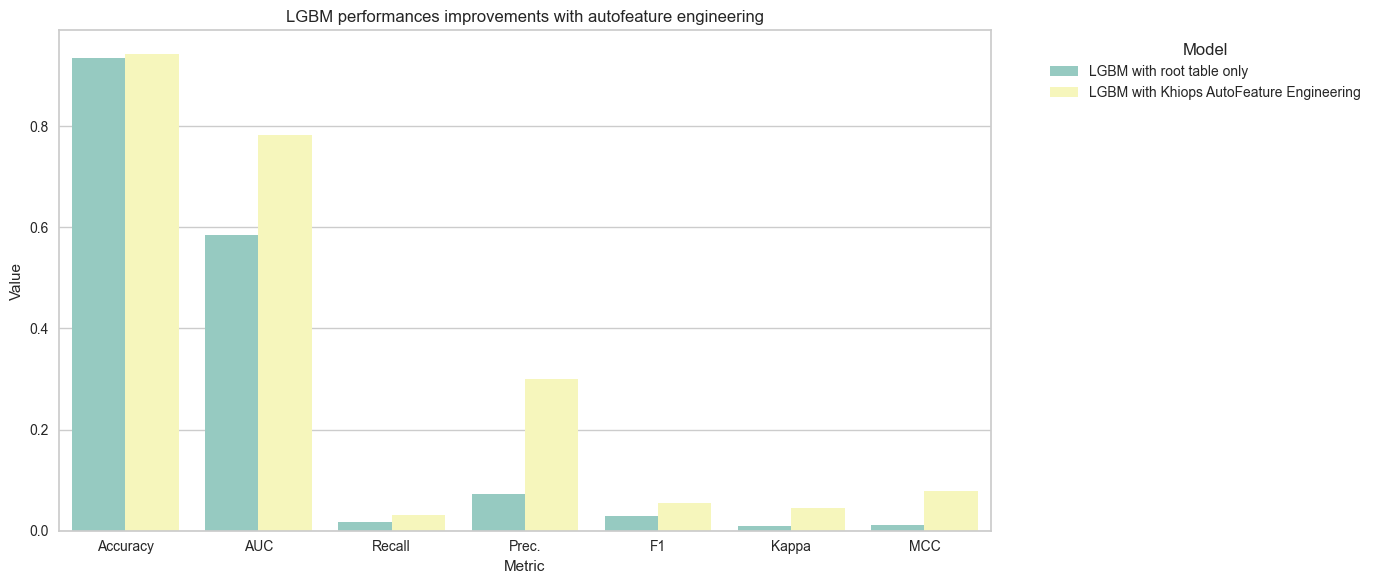

In [17]:
df_plot = results_lgbm.drop("TT (Sec)",axis=1).melt(id_vars=['Model'], var_name='Metric', value_name='Value')

plt.figure(figsize=(14, 6))

# Create a bar plot with Seaborn
sns.barplot(x='Metric', y='Value', hue='Model', data=df_plot, palette="Set3")

plt.title("LGBM performances improvements with autofeature engineering")
plt.ylabel('Value')
plt.xlabel('Metric')

plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Finally, when we compare the performance of the LGBM classifier using, or not, the aggregates generated by Khiops, we appreciate the extent to which the Auto Feature Engineering algorithm is able to extract useful information from the secondary tables. This work would have been painstaking to do by hand, requiring numerous interactions between the data scientist and the business experts, and a great deal of trial and error.  

## Boosting model interpretability with Khiops' end-to-end pipeline

In this section, we use the complete pipeline provided by Khiops, which chains Auto Feature Engineering and Parsimonious Training through a simplistic syntax (a simple fit function). 
Using this pipeline has a number of advantages, it considerably improves model interpretability, it's ultra-easy to use, and it scales very well. 


In [18]:
# we use a KhiopsClassifier to leverage the full pipeline
pkc_accidents = KhiopsClassifier(n_trees=0, n_features=1000)

# Just fit it ! 
pkc_accidents.fit(X_accidents_train, y_accidents_train)

KhiopsClassifier(all_possible_pairs=True, auto_sort=True,
                 construction_rules=None, group_target_value=False,
                 n_evaluated_features=0, n_features=1000, n_pairs=0,
                 n_selected_features=0, n_trees=0, output_dir=None,
                 specific_pairs=None, verbose=False)

In [19]:
# Let's take a look at the classifier's performance on the training set
train_eval = pkc_accidents.model_report_.train_evaluation_report.get_snb_performance()

In [20]:
print(f"Accident train accuracy: {train_eval.accuracy}")
print(f"Accident train AUC     : {train_eval.auc}")

classes = train_eval.confusion_matrix.values
confusion_matrix = pd.DataFrame(
    train_eval.confusion_matrix.matrix,
    columns=classes,
    index=classes,
)
print("Accident train confusion matrix:")
confusion_matrix

Accident train accuracy: 0.945174
Accident train AUC     : 0.8287
Accident train confusion matrix:


,0,1
0,40918,2342
1,34,43


In [21]:
# Let's now take a look at the classifier's performance on the test set
from sklearn import metrics

# Compute predictions and predicted class probabilities on the test dataset
y_accidents_test_predictions = pkc_accidents.predict(X_accidents_test)
y_accidents_test_probas = pkc_accidents.predict_proba(X_accidents_test)

# Compute accuracy and AUC on the test predictions and predicted class probabilities
test_accuracy = metrics.accuracy_score(y_accidents_test, y_accidents_test_predictions)
test_auc = metrics.roc_auc_score(y_accidents_test, y_accidents_test_probas[:, 1])

print(f"Accident test accuracy: {test_accuracy}")
print(f"Accident test AUC     : {test_auc}")


Accident test accuracy: 0.944206008583691
Accident test AUC     : 0.7998927229566926


Now let's take a closer look at the trained model, by examining the aggregates generated by the Auto Feature Engineering step and selected by Parsimonious Training. The next cell shows the names of the selected aggregates, sorted by decreasing *importance*.

The *importance* measures the role that the variable plays in the decisions made by the learned classifier at prediction time (more details [here][parsimonious_training]). It is computed as the average of the absolute Shapley values of the variable over the training dataset.

[encoding]: ../../../learn/preprocessing/#benefits
[parsimonious_training]: ../../../learn/learning_models/

In [23]:
kpis = {"Feature" : [], "Importance": []}

for var in pkc_accidents.model_report_.modeling_report.get_snb_predictor().selected_variables:
    kpis["Feature"].append(var.name)
    kpis["Importance"].append(var.importance)

    
df_kpis = pd.DataFrame(kpis).sort_values(by = 'Importance', ascending=False)
df_kpis.head(10).style.set_properties(subset=['Feature'], **{'width': '400px'})

,Feature,Importance
0,InAgglomeration,0.118142
1,Department,0.088847
2,Commune,0.072805
3,Longitude,0.070819
4,CollisionType,0.057035
5,Count(Vehicles) where Category = Car<=3.5T,0.038857
6,PostalAddress,0.037490
7,CountDistinct(Vehicles.Direction),0.036149
8,Mode(Vehicles.Category) where ImpactPoint = Front,0.034474
9,Max(Vehicles.PassengerNumber) where Category = Car<=3.5T and MobileObstacle = Vehicle,0.032136


As shown in the previous cell, the aggregates generated by khiops are identified by their calculation formula, which greatly facilitates their interpretation. For example, here's what the first three aggregates mean: 

- "Count(Vehicles) where Category = Car<=3.5T" is the number of light car involved in the accident;
- "Mode(Vehicles.Category) where ImpactPoint = Front" majority category of vehicles being struck at the front;
- "CountDistinct(Vehicles.Direction)" is the number of different directions taken by the vehicles involved.

In practice, the models trained by khiops are easy to understand and make it easy to interact with technical experts. To make the link with the figure in the introduction to this notebook, let's now look at how the size of the data representation evolves throughout the pipeline:


In [24]:

# nb generated vs. selected features :
Nb_original_features = len(accidents_df_train.head())
Nb_selected_features = len(df_kpis)

print("Nb original features  = " + str(Nb_original_features))
print("Nb generated features = 1000")
print("Nb selected features  = " + str(Nb_selected_features))


Nb original features  = 5
Nb generated features = 1000
Nb selected features  = 52


This training pipeline starts with 5 features in the main table. The Auto Features Engineering step generates 1000 aggregates (this is a maximum number provided by the user). Then, the Parsimonious Training step selects 52 features out of all those available, in order to find the smallest subset of variables that are collectively the most informative and the most independent of each other. In the end, the resulting model is both accurate and easy to interpret. For more in-depth model interpretation, please consult the page describing the [visualization tool][visu] supplied with Khiops.

[visu]: ../../../setup/visualization/